# Interpretable Telematics-Based Energy Anomaly Detection — final notebook

This notebook is **end-to-end and reproducible**:

1. builds a per-trip table from raw VED files,
2. trains and tunes an **XGBoost regressor**,
3. compares the model against simple **naive baselines**,
4. detects anomalies through **positive residuals on the test split only**,
5. implements **LIME for tabular data from scratch**,
6. saves final artifacts and plots.

Important implementation fixes in this checked version:

- fuel power falls back to **MAF** when `Fuel Rate[L/hr]` is missing,
- battery power sign is flipped so **discharge contributes positive consumption**,
- the default experiment is **PHEV-only**,
- very short trips are removed before training,
- negative targets are dropped,
- **direct target-construction features are excluded from the model and from LIME**,
- the anomaly threshold is calibrated on **out-of-sample validation residuals** only,
- LIME tuning is also calibrated on **out-of-sample validation trips**,
- the grouped naive baseline is chosen only if the grouping column is actually informative.


# 0. Config

In [1]:
from pathlib import Path
import glob
import json
import math
import warnings
from dataclasses import dataclass, asdict
from itertools import product
from zipfile import ZipFile

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pd.options.display.float_format = lambda x: f"{x:.4f}"

WEEK_FILES_GLOB = r"/kaggle/input/datasets/galievilyas/ved-dataset/VED_DynamicData_Part*/VED_*_week.csv"
STATIC_PHEV_EV_XLSX = Path(r"/kaggle/input/datasets/galievilyas/ved-dataset/VED_Static_Data_PHEV_EV.xlsx")
STATIC_ICE_HEV_XLSX = Path(r"/kaggle/input/datasets/galievilyas/ved-dataset/VED_Static_Data_ICE_HEV.xlsx")

# Output folders
PROJECT_ROOT = Path(".").resolve()
OUTPUT_DIR = PROJECT_ROOT / "outputs_final"
CACHE_DIR = OUTPUT_DIR / "cache"
MODEL_DIR = OUTPUT_DIR / "models"
PLOT_DIR = OUTPUT_DIR / "plots"
EXPLAIN_DIR = OUTPUT_DIR / "lime_explanations"

for p in [OUTPUT_DIR, CACHE_DIR, MODEL_DIR, PLOT_DIR, EXPLAIN_DIR]:
    p.mkdir(parents=True, exist_ok=True)

TRIP_TABLE_CACHE = CACHE_DIR / "trip_table_raw.csv.gz"
SCORED_TRIP_TABLE_PATH = CACHE_DIR / "trip_table_scored.csv.gz"
MODEL_ARTIFACT_PATH = MODEL_DIR / "xgb_energy_artifact.joblib"
XGB_TUNING_PATH = CACHE_DIR / "xgb_tuning_results.csv"
LIME_TUNING_PATH = CACHE_DIR / "lime_tuning_results.csv"
EXPLANATION_SUMMARY_PATH = EXPLAIN_DIR / "lime_explanation_summary.csv"

# Recompute the raw trip table because the target construction changed.
USE_CACHED_TRIP_TABLE = False
USE_CACHED_SCORED_TABLE = False
RUN_XGB_TUNING = True
RUN_LIME_TUNING = True

# Experiment setup
TARGET = "energy_per_km"
ID_COLS = ["trip_id", "VehId", "Trip"]

NUMERIC_FEATURES = [
    "duration_min",
    "distance_km",
    "speed_mean",
    "speed_var",
    "accel_mean",
    "accel_var",
    "accel_p95",
    "stop_go_ratio",
    "idle_time_min",
    "fuel_energy_kWh",
    "battery_energy_kWh",
    "ac_energy_kWh",
    "heater_energy_kWh",
    "hv_current_abs_mean",
    "hv_current_abs_p95",
    "hv_voltage_mean",
    "maf_mean",
    "maf_p95",
    "Generalized_Weight",
]

DIRECT_TARGET_COMPONENTS = [
    "fuel_energy_kWh",
    "battery_energy_kWh",
    "ac_energy_kWh",
    "heater_energy_kWh",
]

MODEL_NUMERIC_FEATURES = [col for col in NUMERIC_FEATURES if col not in DIRECT_TARGET_COMPONENTS]

CATEGORICAL_FEATURES = [
    "VehicleType",
    "Vehicle Class",
    "Transmission",
    "Drive Wheels",
]

RAW_FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES
MODEL_RAW_FEATURES = MODEL_NUMERIC_FEATURES + CATEGORICAL_FEATURES
BASELINE_GROUP_CANDIDATES = ["Vehicle Class", "Transmission", "Drive Wheels", "VehicleType"]

ANOMALY_QUANTILE = 0.98
N_EXPLANATIONS = 5
TOP_K_FEATURES = 10
BACKGROUND_SAMPLE_SIZE = 4000

MIN_DISTANCE_KM = 1.0
MIN_DURATION_MIN = 2.0
DROP_NEGATIVE_TARGETS = True
VEHICLE_TYPE_FILTER = "PHEV"  # Set to None to train on all vehicle types
TARGET_TRANSFORM = "log1p"    # Options: None, "log1p"
RUN_WITHIN_VEHICLE_BENCHMARK = True
WITHIN_VEHICLE_TEST_SIZE = 0.2

# VED column names
COL_VEHID = "VehId"
COL_TRIP = "Trip"
COL_TS_MS = "Timestamp(ms)"
COL_SPEED = "Vehicle Speed[km/h]"
COL_FUEL_RATE = "Fuel Rate[L/hr]"
COL_MAF_CANDIDATES = ["MAF[g/sec]", "Mass Air Flow Rate[g/sec]"]

COL_AC_KW = "Air Conditioning Power[kW]"
COL_AC_W = "Air Conditioning Power[Watts]"
COL_HEATER_W = "Heater Power[Watts]"
COL_HV_I = "HV Battery Current[A]"
COL_HV_V = "HV Battery Voltage[V]"

# Conversion constants
GASOLINE_KWH_PER_LITER = 8.9
GASOLINE_DENSITY_G_PER_L = 745.0
STOICH_AFR = 14.64

SPEED_STOP_THRESHOLD = 5.0

print("PROJECT_ROOT =", PROJECT_ROOT)
print("OUTPUT_DIR   =", OUTPUT_DIR)
print("Vehicle type =", VEHICLE_TYPE_FILTER if VEHICLE_TYPE_FILTER is not None else "ALL")
print("Target transform =", TARGET_TRANSFORM if TARGET_TRANSFORM is not None else "identity")
print("Excluded from model as direct target components =", DIRECT_TARGET_COMPONENTS)

PROJECT_ROOT = /kaggle/working
OUTPUT_DIR   = /kaggle/working/outputs_final
Vehicle type = PHEV
Target transform = log1p
Excluded from model as direct target components = ['fuel_energy_kWh', 'battery_energy_kWh', 'ac_energy_kWh', 'heater_energy_kWh']


## 1. Utilities: ingestion, trip aggregation, static merge

In [2]:
def list_week_files(week_files_glob: str) -> list[Path]:
    files = sorted(Path(p) for p in glob.glob(week_files_glob))
    if not files:
        raise FileNotFoundError(
            "No week files matched WEEK_FILES_GLOB. "
            "Fill the TODO path in the config cell first."
        )
    return files


def _first_numeric_column(df: pd.DataFrame, candidates: list[str]) -> np.ndarray | None:
    for col in candidates:
        if col in df.columns:
            return pd.to_numeric(df[col], errors="coerce").to_numpy(dtype=float)
    return None


def _zeros_if_missing(df: pd.DataFrame, col: str) -> np.ndarray:
    if col in df.columns:
        return pd.to_numeric(df[col], errors="coerce").fillna(0.0).to_numpy(dtype=float)
    return np.zeros(len(df), dtype=float)


def maf_to_fuel_rate_lph(maf_gps: np.ndarray) -> np.ndarray:
    fuel_gps = maf_gps / STOICH_AFR
    fuel_lph = fuel_gps / GASOLINE_DENSITY_G_PER_L * 3600.0
    return fuel_lph


def compute_power_components_kW(df: pd.DataFrame) -> dict[str, np.ndarray]:
    n = len(df)

    fuel_rate_lph = np.full(n, np.nan, dtype=float)
    if COL_FUEL_RATE in df.columns:
        fuel_rate_lph = pd.to_numeric(df[COL_FUEL_RATE], errors="coerce").to_numpy(dtype=float)

    maf = _first_numeric_column(df, COL_MAF_CANDIDATES)
    if maf is not None:
        maf_based_lph = maf_to_fuel_rate_lph(maf)
        fuel_rate_lph = np.where(np.isfinite(fuel_rate_lph), fuel_rate_lph, maf_based_lph)

    fuel_rate_lph = np.nan_to_num(fuel_rate_lph, nan=0.0, posinf=0.0, neginf=0.0)
    p_fuel = fuel_rate_lph * GASOLINE_KWH_PER_LITER

    if (COL_HV_I in df.columns) and (COL_HV_V in df.columns):
        i = pd.to_numeric(df[COL_HV_I], errors="coerce").to_numpy(dtype=float)
        v = pd.to_numeric(df[COL_HV_V], errors="coerce").to_numpy(dtype=float)
        p_batt = -(v * i) / 1000.0
        p_batt = np.nan_to_num(p_batt, nan=0.0, posinf=0.0, neginf=0.0)
    else:
        p_batt = np.zeros(n, dtype=float)

    ac = np.zeros(n, dtype=float)
    if COL_AC_KW in df.columns:
        ac += pd.to_numeric(df[COL_AC_KW], errors="coerce").fillna(0.0).to_numpy(dtype=float)
    elif COL_AC_W in df.columns:
        ac += pd.to_numeric(df[COL_AC_W], errors="coerce").fillna(0.0).to_numpy(dtype=float) / 1000.0

    heater = np.zeros(n, dtype=float)
    if COL_HEATER_W in df.columns:
        heater += pd.to_numeric(df[COL_HEATER_W], errors="coerce").fillna(0.0).to_numpy(dtype=float) / 1000.0

    return {
        "fuel": p_fuel,
        "battery": p_batt,
        "ac": ac,
        "heater": heater,
    }


def compute_instant_power_kW(df: pd.DataFrame) -> np.ndarray:
    comps = compute_power_components_kW(df)
    return comps["fuel"] + comps["battery"] + comps["ac"] + comps["heater"]


def integrate_trip_energy_distance(trip_df: pd.DataFrame) -> tuple[float, float, float]:
    trip_df = trip_df.sort_values(COL_TS_MS)
    t = pd.to_numeric(trip_df[COL_TS_MS], errors="coerce").to_numpy() / 1000.0
    if len(t) < 2:
        return 0.0, 0.0, 0.0

    dt = np.diff(t)
    dt = np.clip(dt, 0.0, None)

    speed_kmh = pd.to_numeric(trip_df[COL_SPEED], errors="coerce").fillna(0.0).to_numpy()
    speed_kms = speed_kmh / 3600.0
    p_kW = compute_instant_power_kW(trip_df)

    energy_kWh = float(np.sum(p_kW[:-1] * (dt / 3600.0)))
    distance_km = float(np.sum(speed_kms[:-1] * dt))
    duration_min = float((t[-1] - t[0]) / 60.0)
    return energy_kWh, distance_km, duration_min


def _weighted_mean_and_p95(x: np.ndarray, dt: np.ndarray) -> tuple[float, float]:
    x = np.asarray(x, dtype=float)
    dt = np.asarray(dt, dtype=float)
    mask = np.isfinite(x)
    if mask.sum() == 0:
        return np.nan, np.nan

    x = x[mask]
    if len(dt) == len(mask):
        w = dt[mask]
    else:
        w = np.ones_like(x)

    w = np.clip(w, 0.0, None)
    if float(w.sum()) <= 0.0:
        w = np.ones_like(x)

    mean_value = float(np.average(x, weights=w))
    p95_value = float(np.nanpercentile(x, 95))
    return mean_value, p95_value


def compute_trip_features(trip_df: pd.DataFrame) -> dict:
    trip_df = trip_df.sort_values(COL_TS_MS)
    t = pd.to_numeric(trip_df[COL_TS_MS], errors="coerce").to_numpy() / 1000.0
    if len(t) < 2:
        return {}

    dt = np.diff(t)
    dt = np.clip(dt, 0.0, None)
    dt_sum = float(np.sum(dt)) + 1e-12

    speed_kmh = pd.to_numeric(trip_df[COL_SPEED], errors="coerce").fillna(0.0).to_numpy(dtype=float)
    speed_ms = speed_kmh * (1000.0 / 3600.0)

    w = dt / dt_sum
    speed_mean = float(np.sum(speed_kmh[:-1] * w))
    speed_var = float(np.sum(((speed_kmh[:-1] - speed_mean) ** 2) * w))

    accel = np.diff(speed_ms) / (dt + 1e-12)
    accel = np.nan_to_num(accel, nan=0.0, posinf=0.0, neginf=0.0)
    accel_mean = float(np.sum(accel * w))
    accel_var = float(np.sum(((accel - accel_mean) ** 2) * w))
    accel_p95 = float(np.percentile(accel, 95))

    stop_go_ratio = float(np.sum(dt[speed_kmh[:-1] < SPEED_STOP_THRESHOLD]) / dt_sum)
    idle_time_min = float(np.sum(dt[speed_kmh[:-1] < 0.1]) / 60.0)

    energy_kWh, distance_km, duration_min = integrate_trip_energy_distance(trip_df)
    energy_per_km = np.nan if distance_km <= 1e-6 else energy_kWh / distance_km

    comps = compute_power_components_kW(trip_df)
    fuel_energy_kWh = float(np.sum(comps["fuel"][:-1] * (dt / 3600.0)))
    battery_energy_kWh = float(np.sum(comps["battery"][:-1] * (dt / 3600.0)))
    ac_energy_kWh = float(np.sum(comps["ac"][:-1] * (dt / 3600.0)))
    heater_energy_kWh = float(np.sum(comps["heater"][:-1] * (dt / 3600.0)))

    hv_current = np.abs(_zeros_if_missing(trip_df, COL_HV_I))
    hv_voltage = pd.to_numeric(trip_df[COL_HV_V], errors="coerce").to_numpy(dtype=float) if COL_HV_V in trip_df.columns else np.full(len(trip_df), np.nan)

    maf = _first_numeric_column(trip_df, COL_MAF_CANDIDATES)
    if maf is None:
        maf = np.full(len(trip_df), np.nan)

    hv_current_abs_mean, hv_current_abs_p95 = _weighted_mean_and_p95(hv_current[:-1], dt)
    hv_voltage_mean, _ = _weighted_mean_and_p95(hv_voltage[:-1], dt)
    maf_mean, maf_p95 = _weighted_mean_and_p95(maf[:-1], dt)

    return {
        "duration_min": duration_min,
        "distance_km": distance_km,
        "speed_mean": speed_mean,
        "speed_var": speed_var,
        "accel_mean": accel_mean,
        "accel_var": accel_var,
        "accel_p95": accel_p95,
        "stop_go_ratio": stop_go_ratio,
        "idle_time_min": idle_time_min,
        "fuel_energy_kWh": fuel_energy_kWh,
        "battery_energy_kWh": battery_energy_kWh,
        "ac_energy_kWh": ac_energy_kWh,
        "heater_energy_kWh": heater_energy_kWh,
        "hv_current_abs_mean": hv_current_abs_mean,
        "hv_current_abs_p95": hv_current_abs_p95,
        "hv_voltage_mean": hv_voltage_mean,
        "maf_mean": maf_mean,
        "maf_p95": maf_p95,
        "energy_kWh": energy_kWh,
        "energy_per_km": energy_per_km,
    }


def aggregate_week_file(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    df["trip_id"] = df[COL_VEHID].astype(str) + "_" + df[COL_TRIP].astype(str)

    rows = []
    for trip_id, g in df.groupby("trip_id", sort=False):
        feat = compute_trip_features(g)
        if not feat:
            continue
        feat["trip_id"] = trip_id
        feat["VehId"] = int(g[COL_VEHID].iloc[0])
        feat["Trip"] = int(g[COL_TRIP].iloc[0])
        rows.append(feat)

    return pd.DataFrame(rows)


def load_static_tables(phev_ev_path: Path, ice_hev_path: Path) -> pd.DataFrame:
    if not phev_ev_path.exists():
        raise FileNotFoundError(f"Missing static file: {phev_ev_path}")
    if not ice_hev_path.exists():
        raise FileNotFoundError(f"Missing static file: {ice_hev_path}")

    phev = pd.read_excel(phev_ev_path)
    ice = pd.read_excel(ice_hev_path)

    phev = phev.rename(columns={"EngineType": "VehicleType"})
    ice = ice.rename(columns={"Vehicle Type": "VehicleType"})

    static = pd.concat([phev, ice], ignore_index=True)
    static = static.drop_duplicates(subset=["VehId"]).reset_index(drop=True)
    return static


def prepare_trip_table(
        week_files_glob: str,
        phev_ev_path: Path,
        ice_hev_path: Path,
        cache_path: Path | None = None,
        use_cache: bool = True,
    ) -> pd.DataFrame:

    if use_cache and cache_path is not None and cache_path.exists():
        return pd.read_csv(cache_path)

    week_files = list_week_files(week_files_glob)
    print(f"Found {len(week_files)} dynamic files")

    trip_tables = []
    for i, f in enumerate(week_files, start=1):
        tdf = aggregate_week_file(f)
        trip_tables.append(tdf)
        if i % 5 == 0 or i == len(week_files):
            trips_so_far = sum(len(x) for x in trip_tables)
            print(f"Processed {i}/{len(week_files)} files | trips so far = {trips_so_far}")

    trips = pd.concat(trip_tables, ignore_index=True)

    static_df = load_static_tables(phev_ev_path, ice_hev_path)
    trips = trips.merge(static_df, on="VehId", how="left")

    trips["Generalized_Weight"] = pd.to_numeric(trips["Generalized_Weight"], errors="coerce")

    for col in CATEGORICAL_FEATURES:
        trips[col] = trips[col].astype("string").fillna("NO DATA")

    for col in NUMERIC_FEATURES:
        trips[col] = pd.to_numeric(trips[col], errors="coerce")

    trips = trips.dropna(subset=[TARGET]).reset_index(drop=True)
    trips = trips.loc[
        (trips["distance_km"] >= MIN_DISTANCE_KM) &
        (trips["duration_min"] >= MIN_DURATION_MIN)
    ].reset_index(drop=True)

    if DROP_NEGATIVE_TARGETS:
        trips = trips.loc[trips[TARGET] >= 0.0].reset_index(drop=True)

    if VEHICLE_TYPE_FILTER is not None:
        trips = trips.loc[trips["VehicleType"].astype(str) == str(VEHICLE_TYPE_FILTER)].reset_index(drop=True)

    if cache_path is not None:
        trips.to_csv(cache_path, index=False, compression="gzip")

    return trips


def split_by_vehicle(trips: pd.DataFrame, test_size: float = 0.2, val_size: float = 0.2, seed: int = 42):
    vehicles = trips["VehId"].dropna().unique()
    train_val, test = train_test_split(vehicles, test_size=test_size, random_state=seed)
    train, val = train_test_split(train_val, test_size=val_size / (1.0 - test_size), random_state=seed)
    return (
        trips["VehId"].isin(train),
        trips["VehId"].isin(val),
        trips["VehId"].isin(test),
    )

## 2. Build the raw trip table (cached after the first run)

In [3]:
trips_df = prepare_trip_table(
    week_files_glob=WEEK_FILES_GLOB,
    phev_ev_path=STATIC_PHEV_EV_XLSX,
    ice_hev_path=STATIC_ICE_HEV_XLSX,
    cache_path=TRIP_TABLE_CACHE,
    use_cache=USE_CACHED_TRIP_TABLE,
)

print("trip table shape:", trips_df.shape)
display(trips_df[ID_COLS + RAW_FEATURES + [TARGET]].head())

target_stats = {
    "n_trips": int(len(trips_df)),
    "n_vehicles": int(trips_df["VehId"].nunique()),
    "target_min": float(trips_df[TARGET].min()),
    "target_median": float(trips_df[TARGET].median()),
    "target_mean": float(trips_df[TARGET].mean()),
    "target_max": float(trips_df[TARGET].max()),
    "zero_share": float((trips_df[TARGET] == 0.0).mean()),
}
print(json.dumps(target_stats, indent=2))

display(
    trips_df.groupby("VehicleType")[TARGET]
    .agg(["count", "mean", "median", "min", "max"])
    .sort_values("count", ascending=False)
)

Found 54 dynamic files
Processed 5/54 files | trips so far = 4172
Processed 10/54 files | trips so far = 7715
Processed 15/54 files | trips so far = 11284
Processed 20/54 files | trips so far = 14144
Processed 25/54 files | trips so far = 17367
Processed 30/54 files | trips so far = 20413
Processed 35/54 files | trips so far = 23322
Processed 40/54 files | trips so far = 26008
Processed 45/54 files | trips so far = 28293
Processed 50/54 files | trips so far = 30758
Processed 54/54 files | trips so far = 32552
trip table shape: (3249, 29)


,trip_id,VehId,Trip,duration_min,distance_km,speed_mean,speed_var,accel_mean,accel_var,accel_p95,...,hv_current_abs_p95,hv_voltage_mean,maf_mean,maf_p95,Generalized_Weight,VehicleType,Vehicle Class,Transmission,Drive Wheels,energy_per_km
0,11_1485,11,1485,3.8583,3.2690,50.8352,85.0810,0.0016,0.8729,1.3222,...,88.8000,293.7799,9.4170,33.0200,4000.0000,PHEV,Car,CVT,FWD,0.5494
1,388_636,388,636,6.4317,2.3247,21.6870,390.4393,0.0093,1.7470,2.0590,...,90.5000,299.3191,1.6557,13.0000,4000.0000,PHEV,Car,CVT,FWD,0.4409
2,449_1158,449,1158,2.9183,1.8860,38.7761,468.3627,-0.0485,0.6825,1.0997,...,91.7000,293.8170,0.7100,0.7100,4000.0000,PHEV,Car,CVT,FWD,0.2159
3,497_390,497,390,10.7767,6.3764,35.5011,557.8479,-0.0017,1.3121,1.9802,...,86.0000,344.3651,0.4300,0.4300,3500.0000,PHEV,Car,CVT,FWD,0.2158
4,537_688,537,688,22.6183,7.3755,19.5651,224.3182,-0.0098,1.3564,1.9329,...,60.7500,358.1902,NaN,NaN,3500.0000,PHEV,Car,NO DATA,FWD,0.4137


{
  "n_trips": 3249,
  "n_vehicles": 24,
  "target_min": 0.008370221192282595,
  "target_median": 0.29674029591612133,
  "target_mean": 0.3436948888310514,
  "target_max": 2.2627589773725414,
  "zero_share": 0.0
}


,count,mean,median,min,max
VehicleType,,,,,
PHEV,3249,0.3437,0.2967,0.0084,2.2628


## 3. Train / validation / test split by vehicle id

In [4]:

train_mask, val_mask, test_mask = split_by_vehicle(trips_df, seed=RANDOM_STATE)

trips_df = trips_df.copy()
trips_df["split"] = np.select(
    [train_mask, val_mask, test_mask],
    ["train", "val", "test"],
    default="unknown",
)

train_df = trips_df[trips_df["split"] == "train"].reset_index(drop=True)
val_df = trips_df[trips_df["split"] == "val"].reset_index(drop=True)
test_df = trips_df[trips_df["split"] == "test"].reset_index(drop=True)

print("train:", train_df.shape)
print("val :", val_df.shape)
print("test :", test_df.shape)


train: (1957, 30)
val : (594, 30)
test : (698, 30)


## 4. Design matrix for XGBoost

In [5]:
def safe_numeric_fill_value(s: pd.Series) -> float:
    s = pd.to_numeric(s, errors="coerce")
    median = s.median()
    if not np.isfinite(median):
        return 0.0
    return float(median)


def fill_raw_features(
        df: pd.DataFrame,
        model_numeric_features: list[str] | None = None,
        categorical_features: list[str] | None = None,
        numeric_fill: dict[str, float] | None = None,
    ) -> pd.DataFrame:

    if model_numeric_features is None:
        model_numeric_features = MODEL_NUMERIC_FEATURES
    if categorical_features is None:
        categorical_features = CATEGORICAL_FEATURES

    selected_columns = list(model_numeric_features) + list(categorical_features)
    out = df.reindex(columns=selected_columns).copy()

    for col in model_numeric_features:
        if col not in out.columns:
            out[col] = np.nan

    for col in categorical_features:
        if col not in out.columns:
            out[col] = "NO DATA"

    if numeric_fill is None:
        numeric_fill = {col: safe_numeric_fill_value(out[col]) for col in model_numeric_features}

    for col in model_numeric_features:
        fill_value = numeric_fill.get(col, 0.0)
        if not np.isfinite(fill_value):
            fill_value = 0.0
        out[col] = pd.to_numeric(out[col], errors="coerce").fillna(fill_value)

    for col in categorical_features:
        out[col] = out[col].astype("string").fillna("NO DATA")

    return out


def make_design(
        df: pd.DataFrame,
        design_columns: list[str] | None = None,
        numeric_fill: dict[str, float] | None = None,
    ) -> tuple[pd.DataFrame, dict[str, float], list[str]]:

    raw = fill_raw_features(
        df,
        model_numeric_features=MODEL_NUMERIC_FEATURES,
        categorical_features=CATEGORICAL_FEATURES,
        numeric_fill=numeric_fill,
    )
    X = pd.get_dummies(raw, columns=CATEGORICAL_FEATURES, dummy_na=False)

    if design_columns is None:
        design_columns = list(X.columns)
    X = X.reindex(columns=design_columns, fill_value=0.0)

    if numeric_fill is None:
        numeric_fill = {col: safe_numeric_fill_value(raw[col]) for col in MODEL_NUMERIC_FEATURES}

    return X.astype(float), numeric_fill, list(design_columns)


y_train = train_df[TARGET].astype(float).to_numpy()
y_val = val_df[TARGET].astype(float).to_numpy()
y_test = test_df[TARGET].astype(float).to_numpy()

X_train, numeric_fill_values, design_columns_train = make_design(train_df)
X_val, _, _ = make_design(val_df, design_columns=design_columns_train, numeric_fill=numeric_fill_values)
X_test, _, _ = make_design(test_df, design_columns=design_columns_train, numeric_fill=numeric_fill_values)

print("X_train:", X_train.shape)
print("X_val  :", X_val.shape)
print("X_test :", X_test.shape)


X_train: (1957, 20)
X_val  : (594, 20)
X_test : (698, 20)


## 5. Tune XGBoost on validation RMSE

In [6]:
def rmse(y_true, y_pred) -> float:
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def evaluate_regression(y_true, y_pred) -> dict:
    return {
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "rmse": rmse(y_true, y_pred),
        "r2": float(r2_score(y_true, y_pred)),
    }


def transform_target(y: np.ndarray, transform: str | None) -> np.ndarray:
    y = np.asarray(y, dtype=float)
    if transform is None:
        return y
    if transform == "log1p":
        if np.any(y < 0.0):
            raise ValueError("log1p transform requires non-negative targets")
        return np.log1p(y)
    raise ValueError(f"Unsupported TARGET_TRANSFORM: {transform}")


def inverse_transform_target(y: np.ndarray, transform: str | None) -> np.ndarray:
    y = np.asarray(y, dtype=float)
    if transform is None:
        return y
    if transform == "log1p":
        out = np.expm1(y)
        return np.clip(out, 0.0, None)
    raise ValueError(f"Unsupported TARGET_TRANSFORM: {transform}")


def tune_xgb_regressor(
        X_train: pd.DataFrame,
        y_train: np.ndarray,
        X_val: pd.DataFrame,
        y_val: np.ndarray,
        random_state: int = 42,
        target_transform: str | None = None,
    ) -> pd.DataFrame:

    param_grid = {
        "max_depth": [4, 6],
        "learning_rate": [0.03, 0.05],
        "min_child_weight": [1, 5],
        "reg_lambda": [1.0, 3.0],
    }

    common = {
        "n_estimators": 1500,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "reg_alpha": 0.0,
        "objective": "reg:squarederror",
        "tree_method": "hist",
        "n_jobs": -1,
        "random_state": random_state,
        "early_stopping_rounds": 50,
        "eval_metric": "rmse",
    }

    y_train_fit = transform_target(y_train, target_transform)
    y_val_fit = transform_target(y_val, target_transform)

    rows = []
    all_keys = list(param_grid.keys())
    for values in product(*[param_grid[k] for k in all_keys]):
        params = dict(zip(all_keys, values))
        model = XGBRegressor(**common, **params)
        model.fit(
            X_train,
            y_train_fit,
            eval_set=[(X_val, y_val_fit)],
            verbose=False,
        )

        val_pred = inverse_transform_target(model.predict(X_val), target_transform)
        metrics = evaluate_regression(y_val, val_pred)

        best_iteration = getattr(model, "best_iteration", None)
        best_n_estimators = common["n_estimators"] if best_iteration is None else int(best_iteration) + 1

        row = {**params, **metrics, "best_n_estimators": best_n_estimators}
        rows.append(row)

    result = pd.DataFrame(rows).sort_values(["rmse", "mae"], ascending=[True, True]).reset_index(drop=True)
    return result


if RUN_XGB_TUNING or not XGB_TUNING_PATH.exists():
    xgb_tuning_df = tune_xgb_regressor(
        X_train,
        y_train,
        X_val,
        y_val,
        random_state=RANDOM_STATE,
        target_transform=TARGET_TRANSFORM,
    )
    xgb_tuning_df.to_csv(XGB_TUNING_PATH, index=False)
else:
    xgb_tuning_df = pd.read_csv(XGB_TUNING_PATH)

display(xgb_tuning_df.head(10))

,max_depth,learning_rate,min_child_weight,reg_lambda,mae,rmse,r2,best_n_estimators
0,4,0.0500,1,3.0000,0.0558,0.0861,0.7465,391
1,4,0.0300,1,3.0000,0.0552,0.0864,0.7447,905
2,4,0.0300,5,1.0000,0.0560,0.0865,0.7439,680
3,4,0.0300,5,3.0000,0.0567,0.0870,0.7412,675
4,4,0.0500,5,3.0000,0.0566,0.0870,0.7411,289
5,4,0.0500,5,1.0000,0.0571,0.0870,0.7410,316
6,6,0.0500,5,1.0000,0.0570,0.0870,0.7408,258
7,4,0.0300,1,1.0000,0.0577,0.0871,0.7404,389
8,4,0.0500,1,1.0000,0.0572,0.0877,0.7368,299
9,6,0.0300,5,1.0000,0.0573,0.0880,0.7352,492


## 6. Fit the final XGBoost model on train + val using the selected number of trees

In [7]:
def predict_constant(y_like: np.ndarray, constant_value: float) -> np.ndarray:
    return np.full_like(y_like, fill_value=constant_value, dtype=float)


def predict_group_median(
        train_df: pd.DataFrame,
        test_df: pd.DataFrame,
        target_col: str,
        group_col: str,
    ) -> np.ndarray:

    global_median = float(train_df[target_col].median())
    group_medians = train_df.groupby(group_col)[target_col].median().to_dict()

    pred = test_df[group_col].map(group_medians).fillna(global_median).to_numpy(dtype=float)
    return pred


def choose_group_baseline_column(train_df: pd.DataFrame, candidates: list[str]) -> str | None:
    for col in candidates:
        if col not in train_df.columns:
            continue
        nunique = int(train_df[col].astype("string").fillna("NO DATA").nunique())
        if nunique > 1:
            return col
    return None


best_xgb_row = xgb_tuning_df.iloc[0].to_dict()
best_xgb_params = {
    "max_depth": int(best_xgb_row["max_depth"]),
    "learning_rate": float(best_xgb_row["learning_rate"]),
    "min_child_weight": int(best_xgb_row["min_child_weight"]),
    "reg_lambda": float(best_xgb_row["reg_lambda"]),
    "n_estimators": int(best_xgb_row["best_n_estimators"]),
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "reg_alpha": 0.0,
    "objective": "reg:squarederror",
    "tree_method": "hist",
    "n_jobs": -1,
    "random_state": RANDOM_STATE,
    "eval_metric": "rmse",
}

# Step 1: fit on train only and score validation out-of-sample.
calibration_model = XGBRegressor(**best_xgb_params)
calibration_model.fit(
    X_train,
    transform_target(y_train, TARGET_TRANSFORM),
    verbose=False,
)

val_pred_calibration = inverse_transform_target(calibration_model.predict(X_val), TARGET_TRANSFORM)
val_scored_df = val_df.copy()
val_scored_df["predicted_energy_per_km"] = val_pred_calibration
val_scored_df["residual"] = val_scored_df[TARGET] - val_scored_df["predicted_energy_per_km"]

validation_residual_threshold = float(np.quantile(val_scored_df["residual"], ANOMALY_QUANTILE))

# Step 2: refit on train + val for the final test evaluation.
train_val_df = pd.concat([train_df, val_df], ignore_index=True)
y_train_val = train_val_df[TARGET].astype(float).to_numpy()
y_train_val_fit = transform_target(y_train_val, TARGET_TRANSFORM)
X_train_val, numeric_fill_values_final, design_columns_final = make_design(train_val_df)

final_model = XGBRegressor(**best_xgb_params)
final_model.fit(X_train_val, y_train_val_fit, verbose=False)

X_test_final, _, _ = make_design(
    test_df,
    design_columns=design_columns_final,
    numeric_fill=numeric_fill_values_final,
)

test_pred = inverse_transform_target(final_model.predict(X_test_final), TARGET_TRANSFORM)
test_metrics = evaluate_regression(y_test, test_pred)

global_median_value = float(train_val_df[TARGET].median())
global_median_pred = predict_constant(y_test, global_median_value)

baseline_rows = [
    {"model": "global_median", **evaluate_regression(y_test, global_median_pred)},
]

baseline_group_col = choose_group_baseline_column(train_val_df, BASELINE_GROUP_CANDIDATES)
if baseline_group_col is not None:
    group_median_pred = predict_group_median(
        train_df=train_val_df,
        test_df=test_df,
        target_col=TARGET,
        group_col=baseline_group_col,
    )
    baseline_rows.append({
        "model": f"{baseline_group_col}_median",
        **evaluate_regression(y_test, group_median_pred),
    })

baseline_rows.append({"model": "xgboost", **test_metrics})

baseline_metrics = (
    pd.DataFrame(baseline_rows)
    .sort_values(["rmse", "mae"], ascending=[True, True])
    .reset_index(drop=True)
)

print("Selected XGBoost params:")
print(json.dumps(best_xgb_params, indent=2))
print("\nValidation residual threshold (out-of-sample):", validation_residual_threshold)
print("\nTest metrics:")
print(json.dumps(test_metrics, indent=2))
print("\nBaseline comparison:")
display(baseline_metrics)


Selected XGBoost params:
{
  "max_depth": 4,
  "learning_rate": 0.05,
  "min_child_weight": 1,
  "reg_lambda": 3.0,
  "n_estimators": 391,
  "subsample": 0.8,
  "colsample_bytree": 0.8,
  "reg_alpha": 0.0,
  "objective": "reg:squarederror",
  "tree_method": "hist",
  "n_jobs": -1,
  "random_state": 42,
  "eval_metric": "rmse"
}

Validation residual threshold (out-of-sample): 0.1649406197552176

Test metrics:
{
  "mae": 0.06695865829022944,
  "rmse": 0.13324230969462472,
  "r2": 0.5376686933535506
}

Baseline comparison:


,model,mae,rmse,r2
0,xgboost,0.0670,0.1332,0.5377
1,Transmission_median,0.1461,0.2320,-0.4021
2,global_median,0.1574,0.2383,-0.4785


## 7. Score all trips and save the final table with raw features + residuals

This is the important fix missing from the previous pipeline:  
for LIME we need the **raw feature row** of every explained trip, not only residuals.


In [8]:
def predict_blackbox_from_design(X_design: pd.DataFrame, artifact: dict) -> np.ndarray:
    raw_pred = artifact["model"].predict(X_design)
    return inverse_transform_target(raw_pred, artifact.get("target_transform"))


def predict_on_raw(df_raw: pd.DataFrame, model_artifact: dict) -> np.ndarray:
    X, _, _ = make_design(
        df_raw,
        design_columns=model_artifact["design_columns"],
        numeric_fill=model_artifact["numeric_fill_values"],
    )
    return predict_blackbox_from_design(X, model_artifact)


scored_df = trips_df.copy()
provisional_artifact = {
    "model": final_model,
    "design_columns": design_columns_final,
    "numeric_fill_values": numeric_fill_values_final,
    "target_transform": TARGET_TRANSFORM,
}
scored_df["predicted_energy_per_km"] = predict_on_raw(
    scored_df[MODEL_RAW_FEATURES],
    model_artifact=provisional_artifact,
)

scored_df["residual"] = scored_df[TARGET] - scored_df["predicted_energy_per_km"]

scored_df.to_csv(SCORED_TRIP_TABLE_PATH, index=False, compression="gzip")

artifact = {
    "model": final_model,
    "design_columns": design_columns_final,
    "numeric_fill_values": numeric_fill_values_final,
    "raw_feature_columns": MODEL_RAW_FEATURES,
    "all_raw_feature_columns": RAW_FEATURES,
    "numeric_feature_columns": MODEL_NUMERIC_FEATURES,
    "all_numeric_feature_columns": NUMERIC_FEATURES,
    "categorical_feature_columns": CATEGORICAL_FEATURES,
    "background_raw": train_df[MODEL_RAW_FEATURES].sample(
        n=min(BACKGROUND_SAMPLE_SIZE, len(train_df)),
        random_state=RANDOM_STATE,
    ).reset_index(drop=True),
    "best_xgb_params": best_xgb_params,
    "test_metrics": test_metrics,
    "baseline_metrics": baseline_metrics.to_dict(orient="records"),
    "vehicle_type_filter": VEHICLE_TYPE_FILTER,
    "min_distance_km": MIN_DISTANCE_KM,
    "min_duration_min": MIN_DURATION_MIN,
    "target_transform": TARGET_TRANSFORM,
}

joblib.dump(artifact, MODEL_ARTIFACT_PATH)

print("Saved scored trip table:", SCORED_TRIP_TABLE_PATH)
print("Saved model artifact   :", MODEL_ARTIFACT_PATH)

display(scored_df[ID_COLS + RAW_FEATURES + [TARGET, "predicted_energy_per_km", "residual", "split"]].head())

Saved scored trip table: /kaggle/working/outputs_final/cache/trip_table_scored.csv.gz
Saved model artifact   : /kaggle/working/outputs_final/models/xgb_energy_artifact.joblib


,trip_id,VehId,Trip,duration_min,distance_km,speed_mean,speed_var,accel_mean,accel_var,accel_p95,...,maf_p95,Generalized_Weight,VehicleType,Vehicle Class,Transmission,Drive Wheels,energy_per_km,predicted_energy_per_km,residual,split
0,11_1485,11,1485,3.8583,3.2690,50.8352,85.0810,0.0016,0.8729,1.3222,...,33.0200,4000.0000,PHEV,Car,CVT,FWD,0.5494,0.5428,0.0066,test
1,388_636,388,636,6.4317,2.3247,21.6870,390.4393,0.0093,1.7470,2.0590,...,13.0000,4000.0000,PHEV,Car,CVT,FWD,0.4409,0.4210,0.0200,train
2,449_1158,449,1158,2.9183,1.8860,38.7761,468.3627,-0.0485,0.6825,1.0997,...,0.7100,4000.0000,PHEV,Car,CVT,FWD,0.2159,0.1950,0.0209,val
3,497_390,497,390,10.7767,6.3764,35.5011,557.8479,-0.0017,1.3121,1.9802,...,0.4300,3500.0000,PHEV,Car,CVT,FWD,0.2158,0.1796,0.0362,val
4,537_688,537,688,22.6183,7.3755,19.5651,224.3182,-0.0098,1.3564,1.9329,...,NaN,3500.0000,PHEV,Car,NO DATA,FWD,0.4137,0.4484,-0.0347,train


## 8. Basic diagnostics

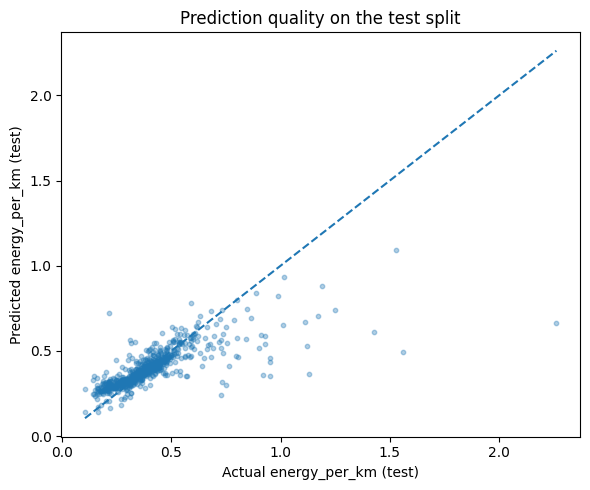

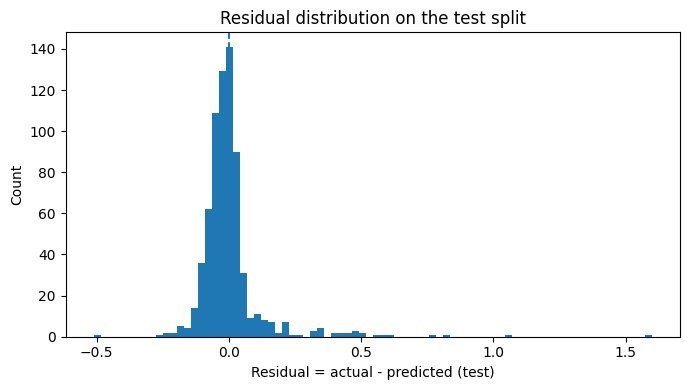

In [9]:
test_scored_df = scored_df.loc[scored_df["split"] == "test"].copy()

fig = plt.figure(figsize=(6, 5))
plt.scatter(
    test_scored_df[TARGET],
    test_scored_df["predicted_energy_per_km"],
    s=10,
    alpha=0.35,
)

vmin = float(min(test_scored_df[TARGET].min(), test_scored_df["predicted_energy_per_km"].min()))
vmax = float(max(test_scored_df[TARGET].max(), test_scored_df["predicted_energy_per_km"].max()))
plt.plot([vmin, vmax], [vmin, vmax], linestyle="--")
plt.xlabel("Actual energy_per_km (test)")
plt.ylabel("Predicted energy_per_km (test)")
plt.title("Prediction quality on the test split")
plt.tight_layout()
plt.savefig(PLOT_DIR / "predicted_vs_actual_test.png", dpi=150, bbox_inches="tight")
plt.show()

fig = plt.figure(figsize=(7, 4))
plt.hist(test_scored_df["residual"], bins=80)
plt.axvline(0.0, linestyle="--")
plt.xlabel("Residual = actual - predicted (test)")
plt.ylabel("Count")
plt.title("Residual distribution on the test split")
plt.tight_layout()
plt.savefig(PLOT_DIR / "residual_distribution_test.png", dpi=150, bbox_inches="tight")
plt.show()

## 8b. Cross-vehicle diagnostics and a second evaluation protocol

Per-vehicle metrics on the unseen-vehicle test split:


,VehId,n_trips,actual_mean,pred_mean,mae,rmse,r2
0,536,62.0000,0.7626,0.5303,0.2689,0.3466,-0.4561
1,560,377.0000,0.3736,0.3815,0.0366,0.0933,0.5192
2,11,143.0000,0.3120,0.3632,0.0693,0.0864,0.6288
3,443,53.0000,0.4349,0.4099,0.0537,0.0723,0.7011
4,417,63.0000,0.3896,0.4313,0.0555,0.0715,0.7815


Worst unseen vehicle on test: VehId=536


,feature,worst_vehicle_mean,train_val_mean,z_like_gap
0,accel_p95,2.0824,1.6265,0.9497
1,fuel_energy_kWh,3.4657,1.2341,0.6695
2,battery_energy_kWh,0.0521,0.7867,-0.5928
3,stop_go_ratio,0.2435,0.1978,0.3261
4,duration_min,7.3966,9.8908,-0.3016
5,idle_time_min,1.3410,2.0601,-0.2115
6,speed_mean,37.2308,39.7901,-0.1899
7,distance_km,5.6409,6.1794,-0.0791
8,hv_current_abs_mean,31.4215,30.8578,0.0481
9,maf_mean,NaN,3.0846,NaN


,trip_id,VehId,Trip,energy_per_km,predicted_energy_per_km,residual,duration_min,distance_km,speed_mean,speed_var,...,fuel_energy_kWh,battery_energy_kWh,ac_energy_kWh,heater_energy_kWh,hv_current_abs_mean,hv_current_abs_p95,hv_voltage_mean,maf_mean,maf_p95,Generalized_Weight
360,536_340,536,340,1.5590,0.4924,1.0666,3.2617,1.5723,28.9239,634.1611,...,2.4516,-0.0003,0.0000,0.0000,33.1493,104.4000,339.4396,NaN,NaN,4000.0000
415,536_370,536,370,1.4280,0.6133,0.8147,2.1767,1.1501,31.7036,100.7217,...,1.9237,-0.2813,0.0000,0.0000,33.7807,55.7250,347.4493,NaN,NaN,4000.0000
872,536_544,536,544,1.1299,0.3671,0.7628,3.1883,3.0854,58.0622,179.4364,...,3.6439,-0.1578,0.0000,0.0000,33.1466,80.7000,343.8496,NaN,NaN,4000.0000
1175,536_643,536,643,0.9522,0.3504,0.6018,4.6517,3.2020,41.3009,735.9899,...,3.2023,-0.1533,0.0000,0.0000,30.4004,107.8500,342.3611,NaN,NaN,4000.0000
2694,536_986,536,986,1.1213,0.5260,0.5953,2.4100,2.0733,51.6166,636.1269,...,2.3511,-0.1360,0.1098,0.0000,32.6537,80.4000,340.8109,NaN,NaN,4000.0000
780,536_498,536,498,0.9215,0.3594,0.5621,3.7550,2.1515,34.3779,683.2823,...,2.1756,-0.1931,0.0000,0.0000,34.6071,102.7500,345.1561,NaN,NaN,4000.0000
120,536_267,536,267,0.9529,0.4362,0.5166,4.7183,2.4052,30.5853,727.7481,...,2.3529,-0.0610,0.0000,0.0000,26.8335,109.8000,342.0827,NaN,NaN,4000.0000
2166,536_868,536,868,1.2510,0.7425,0.5084,11.3350,2.7665,14.6441,402.8782,...,3.2685,0.0220,0.1704,0.0000,17.8869,79.8000,339.7772,NaN,NaN,4000.0000
1369,536_700,536,700,0.9509,0.4607,0.4902,4.8967,3.2075,39.3019,418.5724,...,3.3178,-0.2678,0.0000,0.0000,40.7325,105.1800,343.1993,NaN,NaN,4000.0000
131,536_276,536,276,0.7257,0.2395,0.4862,6.7117,6.9061,61.7378,1486.4387,...,5.3648,-0.3531,0.0000,0.0000,40.1021,114.5325,344.4732,NaN,NaN,4000.0000


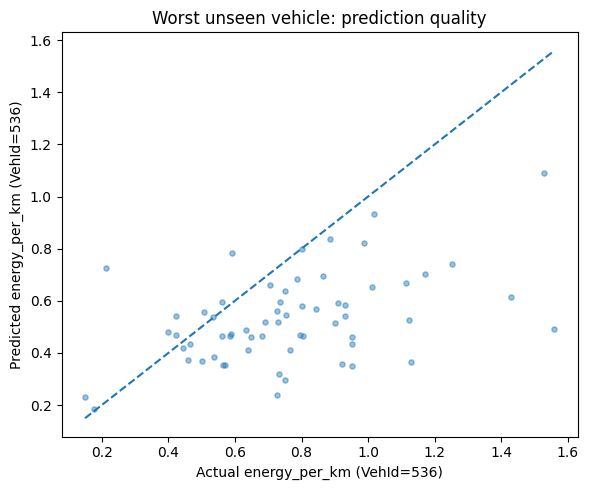

How much harder is the unseen-vehicle setting?


,setting,mae,rmse,r2
0,unseen_vehicle_test,0.0670,0.1332,0.5377
1,within_vehicle_trip_split,0.0515,0.0966,0.7256


In [10]:
test_vehicle_metrics = (
    test_scored_df.groupby("VehId")
    .apply(lambda g: pd.Series({
        "n_trips": int(len(g)),
        "actual_mean": float(g[TARGET].mean()),
        "pred_mean": float(g["predicted_energy_per_km"].mean()),
        "mae": float(mean_absolute_error(g[TARGET], g["predicted_energy_per_km"])),
        "rmse": rmse(g[TARGET], g["predicted_energy_per_km"]),
        "r2": float(r2_score(g[TARGET], g["predicted_energy_per_km"])) if len(g) > 1 else np.nan,
    }))
    .reset_index()
    .sort_values(["rmse", "mae"], ascending=[False, False])
    .reset_index(drop=True)
)

print("Per-vehicle metrics on the unseen-vehicle test split:")
display(test_vehicle_metrics)

worst_vehicle_id = int(test_vehicle_metrics.iloc[0]["VehId"])
worst_vehicle_df = test_scored_df.loc[test_scored_df["VehId"] == worst_vehicle_id].copy()
train_reference_df = scored_df.loc[scored_df["split"].isin(["train", "val"])].copy()

comparison_features = [
    "distance_km",
    "duration_min",
    "speed_mean",
    "accel_p95",
    "stop_go_ratio",
    "idle_time_min",
    "fuel_energy_kWh",
    "battery_energy_kWh",
    "hv_current_abs_mean",
    "maf_mean",
]

vehicle_profile = pd.DataFrame({
    "feature": comparison_features,
    "worst_vehicle_mean": [float(worst_vehicle_df[f].mean()) for f in comparison_features],
    "train_val_mean": [float(train_reference_df[f].mean()) for f in comparison_features],
    "z_like_gap": [
        float(
            (worst_vehicle_df[f].mean() - train_reference_df[f].mean()) /
            (train_reference_df[f].std(ddof=0) + 1e-12)
        )
        for f in comparison_features
    ],
}).sort_values("z_like_gap", key=lambda s: s.abs(), ascending=False).reset_index(drop=True)

print(f"Worst unseen vehicle on test: VehId={worst_vehicle_id}")
display(vehicle_profile)

display(
    worst_vehicle_df[[ "trip_id", "VehId", "Trip", TARGET, "predicted_energy_per_km", "residual" ] + NUMERIC_FEATURES]
    .sort_values("residual", ascending=False)
    .head(10)
)

fig = plt.figure(figsize=(6, 5))
plt.scatter(
    worst_vehicle_df[TARGET],
    worst_vehicle_df["predicted_energy_per_km"],
    s=14,
    alpha=0.45,
)
vmin = float(min(worst_vehicle_df[TARGET].min(), worst_vehicle_df["predicted_energy_per_km"].min()))
vmax = float(max(worst_vehicle_df[TARGET].max(), worst_vehicle_df["predicted_energy_per_km"].max()))
plt.plot([vmin, vmax], [vmin, vmax], linestyle="--")
plt.xlabel(f"Actual energy_per_km (VehId={worst_vehicle_id})")
plt.ylabel(f"Predicted energy_per_km (VehId={worst_vehicle_id})")
plt.title("Worst unseen vehicle: prediction quality")
plt.tight_layout()
plt.savefig(PLOT_DIR / f"worst_vehicle_{worst_vehicle_id}_predicted_vs_actual.png", dpi=150, bbox_inches="tight")
plt.show()

if RUN_WITHIN_VEHICLE_BENCHMARK:
    within_train_df, within_test_df = train_test_split(
        trips_df,
        test_size=WITHIN_VEHICLE_TEST_SIZE,
        random_state=RANDOM_STATE,
    )

    X_within_train, within_numeric_fill, within_design_cols = make_design(within_train_df)
    X_within_test, _, _ = make_design(
        within_test_df,
        design_columns=within_design_cols,
        numeric_fill=within_numeric_fill,
    )

    y_within_train = within_train_df[TARGET].to_numpy(dtype=float)
    y_within_test = within_test_df[TARGET].to_numpy(dtype=float)

    within_model = XGBRegressor(**best_xgb_params)
    within_model.fit(
        X_within_train,
        transform_target(y_within_train, TARGET_TRANSFORM),
        verbose=False,
    )
    within_pred = inverse_transform_target(within_model.predict(X_within_test), TARGET_TRANSFORM)

    within_vehicle_metrics = evaluate_regression(y_within_test, within_pred)

    comparison_df = pd.DataFrame([
        {"setting": "unseen_vehicle_test", **test_metrics},
        {"setting": "within_vehicle_trip_split", **within_vehicle_metrics},
    ])

    print("How much harder is the unseen-vehicle setting?")
    display(comparison_df)

## 9. Residual-based anomaly detection

In [11]:
def positive_quantile_threshold(residuals: pd.Series, q: float = 0.98) -> float:
    if not (0.0 < q < 1.0):
        raise ValueError("q must be in (0, 1)")
    return float(np.quantile(residuals.astype(float), q))


test_mask = scored_df["split"] == "test"

residual_threshold = positive_quantile_threshold(
    val_scored_df["residual"],
    q=ANOMALY_QUANTILE,
)

scored_df["is_anomaly"] = False
scored_df.loc[test_mask, "is_anomaly"] = scored_df.loc[test_mask, "residual"] >= residual_threshold

n_anomalies = int(scored_df.loc[test_mask, "is_anomaly"].sum())
share_anomalies = float(scored_df.loc[test_mask, "is_anomaly"].mean())

print("Residual threshold from out-of-sample validation residuals:", residual_threshold)
print("Test anomalies:", n_anomalies)
print("Test anomaly share:", share_anomalies)

vehicle_anomaly_counts = (
    scored_df.loc[test_mask]
    .groupby("VehId")["is_anomaly"]
    .agg(["sum", "mean", "count"])
    .rename(columns={"sum": "anomaly_count", "mean": "anomaly_share", "count": "n_test_trips"})
    .sort_values(["anomaly_count", "anomaly_share"], ascending=[False, False])
    .reset_index()
)

print("Anomalies by unseen test vehicle:")
display(vehicle_anomaly_counts)

display(
    scored_df.loc[scored_df["is_anomaly"], ID_COLS + RAW_FEATURES + [TARGET, "predicted_energy_per_km", "residual", "split"]]
    .sort_values("residual", ascending=False)
    .head(10)
)

# Save the enriched scored table with the anomaly flag.
scored_df.to_csv(SCORED_TRIP_TABLE_PATH, index=False, compression="gzip")
print("Updated scored trip table with anomaly flag:", SCORED_TRIP_TABLE_PATH)


Residual threshold from out-of-sample validation residuals: 0.1649406197552176
Test anomalies: 41
Test anomaly share: 0.05873925501432665
Anomalies by unseen test vehicle:


,VehId,anomaly_count,anomaly_share,n_test_trips
0,536,36,0.5806,62
1,443,2,0.0377,53
2,560,2,0.0053,377
3,11,1,0.0070,143
4,417,0,0.0000,63


,trip_id,VehId,Trip,duration_min,distance_km,speed_mean,speed_var,accel_mean,accel_var,accel_p95,...,maf_p95,Generalized_Weight,VehicleType,Vehicle Class,Transmission,Drive Wheels,energy_per_km,predicted_energy_per_km,residual,split
380,560_141,560,141,11.2167,9.9081,53.0000,0.0000,0.0000,0.0000,0.0000,...,40.2300,3000.0000,PHEV,Car,CVT,FWD,2.2628,0.6627,1.6001,test
360,536_340,536,340,3.2617,1.5723,28.9239,634.1611,-0.0395,1.3893,1.9111,...,NaN,4000.0000,PHEV,Car,NO DATA,FWD,1.5590,0.4924,1.0666,test
415,536_370,536,370,2.1767,1.1501,31.7036,100.7217,-0.0095,1.1223,1.6276,...,NaN,4000.0000,PHEV,Car,NO DATA,FWD,1.4280,0.6133,0.8147,test
872,536_544,536,544,3.1883,3.0854,58.0622,179.4364,-0.0317,0.9376,1.2905,...,NaN,4000.0000,PHEV,Car,NO DATA,FWD,1.1299,0.3671,0.7628,test
1175,536_643,536,643,4.6517,3.2020,41.3009,735.9899,-0.0356,1.5579,1.9531,...,NaN,4000.0000,PHEV,Car,NO DATA,FWD,0.9522,0.3504,0.6018,test
2694,536_986,536,986,2.4100,2.0733,51.6166,636.1269,0.0209,1.0748,1.3581,...,NaN,4000.0000,PHEV,Car,NO DATA,FWD,1.1213,0.5260,0.5953,test
780,536_498,536,498,3.7550,2.1515,34.3779,683.2823,-0.0322,1.0256,1.6645,...,NaN,4000.0000,PHEV,Car,NO DATA,FWD,0.9215,0.3594,0.5621,test
120,536_267,536,267,4.7183,2.4052,30.5853,727.7481,-0.0110,1.4012,1.7839,...,NaN,4000.0000,PHEV,Car,NO DATA,FWD,0.9529,0.4362,0.5166,test
2166,536_868,536,868,11.3350,2.7665,14.6441,402.8782,-0.0013,1.1965,2.0898,...,NaN,4000.0000,PHEV,Car,NO DATA,FWD,1.2510,0.7425,0.5084,test
1369,536_700,536,700,4.8967,3.2075,39.3019,418.5724,0.0273,2.5199,2.4015,...,NaN,4000.0000,PHEV,Car,NO DATA,FWD,0.9509,0.4607,0.4902,test


Updated scored trip table with anomaly flag: /kaggle/working/outputs_final/cache/trip_table_scored.csv.gz


## 10. Manual LIME implementation and fidelity-aware tuning

In [12]:
@dataclass
class LimeExplanation:
    trip_id: str
    blackbox_prediction: float
    surrogate_prediction_at_x0: float
    x0_abs_gap: float
    intercept: float
    kernel_width: float
    local_r2: float
    local_rmse: float
    top_features: list[tuple[str, float]]

def sample_background_stats(background_raw: pd.DataFrame):
    stats = {}
    for col in MODEL_NUMERIC_FEATURES:
        x = pd.to_numeric(background_raw[col], errors="coerce").astype(float).dropna()

        if len(x) == 0:
            mean_ = 0.0
            sigma = 1.0
            q01 = -3.0
            q99 = 3.0
        else:
            mean_ = float(x.mean())
            sigma = float(x.std(ddof=0))
            if not np.isfinite(sigma) or sigma < 1e-12:
                sigma = 1.0

            q01 = float(x.quantile(0.01))
            q99 = float(x.quantile(0.99))

            if not np.isfinite(q01):
                q01 = mean_ - 3.0 * sigma
            if not np.isfinite(q99):
                q99 = mean_ + 3.0 * sigma
            if q01 > q99:
                q01, q99 = mean_ - 3.0 * sigma, mean_ + 3.0 * sigma

        stats[col] = {
            "mean": mean_,
            "std": sigma,
            "q01": q01,
            "q99": q99,
        }

    cat_probs = {}
    for col in CATEGORICAL_FEATURES:
        vc = background_raw[col].astype("string").fillna("NO DATA").value_counts(normalize=True)
        if len(vc) == 0:
            cat_probs[col] = {"values": ["NO DATA"], "probs": [1.0]}
        else:
            cat_probs[col] = {
                "values": vc.index.astype(str).tolist(),
                "probs": vc.values.astype(float),
            }
    return stats, cat_probs

def perturb_raw_instance(
        x0_raw: pd.Series,
        background_raw: pd.DataFrame,
        n_samples: int,
        random_state: int = 42,
    ) -> pd.DataFrame:

    rng = np.random.default_rng(random_state)
    num_stats, cat_probs = sample_background_stats(background_raw)

    Z = pd.DataFrame(index=range(n_samples), columns=MODEL_RAW_FEATURES)

    for col in MODEL_NUMERIC_FEATURES:
        s = num_stats[col]
        loc = pd.to_numeric(pd.Series([x0_raw.get(col, np.nan)]), errors="coerce").iloc[0]
        if not np.isfinite(loc):
            loc = s["mean"]

        z = rng.normal(loc=float(loc), scale=float(s["std"]), size=n_samples)
        z = np.clip(z, float(s["q01"]), float(s["q99"]))
        z = np.nan_to_num(z, nan=float(s["mean"]), posinf=float(s["q99"]), neginf=float(s["q01"]))
        Z[col] = z.astype(float)

    for col in CATEGORICAL_FEATURES:
        values = np.array(cat_probs[col]["values"], dtype=object)
        probs = np.array(cat_probs[col]["probs"], dtype=float)
        if len(values) == 0 or not np.isfinite(probs).all() or probs.sum() <= 0:
            values = np.array(["NO DATA"], dtype=object)
            probs = np.array([1.0], dtype=float)
        probs = probs / probs.sum()
        Z[col] = rng.choice(values, size=n_samples, replace=True, p=probs)

    x0_copy = x0_raw[MODEL_RAW_FEATURES].copy()
    for col in MODEL_NUMERIC_FEATURES:
        if not np.isfinite(pd.to_numeric(pd.Series([x0_copy.get(col, np.nan)]), errors="coerce").iloc[0]):
            x0_copy[col] = num_stats[col]["mean"]
    for col in CATEGORICAL_FEATURES:
        if pd.isna(x0_copy.get(col, np.nan)):
            x0_copy[col] = "NO DATA"

    Z.iloc[0] = x0_copy
    return Z

def make_interpretable_matrix(
        df_raw: pd.DataFrame,
        background_raw: pd.DataFrame,
    ) -> pd.DataFrame:

    num_stats, _ = sample_background_stats(background_raw)

    parts = []

    num_df = pd.DataFrame(index=df_raw.index)
    for col in MODEL_NUMERIC_FEATURES:
        mean_ = num_stats[col]["mean"]
        std_ = num_stats[col]["std"]
        x = pd.to_numeric(df_raw[col], errors="coerce").astype(float).fillna(mean_)
        num_df[col] = (x - mean_) / std_
    parts.append(num_df)

    for col in CATEGORICAL_FEATURES:
        bg_levels = background_raw[col].astype("string").fillna("NO DATA").astype(str)
        df_levels = df_raw[col].astype("string").fillna("NO DATA").astype(str)
        categories = sorted(set(bg_levels.unique()) | set(df_levels.unique()) | {"NO DATA"})
        s = pd.Categorical(df_levels, categories=categories)
        dummies = pd.get_dummies(s, prefix=col, prefix_sep="=", dtype=float)
        dummies.index = df_raw.index
        parts.append(dummies)

    out = pd.concat(parts, axis=1).astype(float)
    out = out.replace([np.inf, -np.inf], np.nan).fillna(0.0)
    return out

def pairwise_distance_to_x0(Z_interp: np.ndarray, x0_interp: np.ndarray) -> np.ndarray:
    Z_interp = np.nan_to_num(np.asarray(Z_interp, dtype=float), nan=0.0, posinf=0.0, neginf=0.0)
    x0_interp = np.nan_to_num(np.asarray(x0_interp, dtype=float), nan=0.0, posinf=0.0, neginf=0.0)
    return np.sqrt(np.sum((Z_interp - x0_interp[None, :]) ** 2, axis=1))

def kernel_weights(distances: np.ndarray, kernel_width: float) -> np.ndarray:
    distances = np.nan_to_num(np.asarray(distances, dtype=float), nan=1e6, posinf=1e6, neginf=1e6)
    kernel_width = max(float(kernel_width), 1e-6)
    w = np.exp(-(distances ** 2) / (kernel_width ** 2 + 1e-12))
    w = np.nan_to_num(w, nan=0.0, posinf=1.0, neginf=0.0)
    return np.clip(w, 1e-12, None)

def weighted_ridge_closed_form(X: np.ndarray, y: np.ndarray, w: np.ndarray, alpha: float) -> tuple[np.ndarray, float]:
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float).reshape(-1)
    w = np.asarray(w, dtype=float).reshape(-1)

    if X.ndim != 2:
        raise ValueError("X must be 2D")

    mask = (
        np.isfinite(y) &
        np.isfinite(w) &
        (w > 0) &
        np.all(np.isfinite(X), axis=1)
    )

    X = X[mask]
    y = y[mask]
    w = w[mask]

    n, d = X.shape

    if n == 0:
        return np.zeros(d, dtype=float), 0.0

    if n == 1:
        return np.zeros(d, dtype=float), float(y[0])

    X1 = np.concatenate([np.ones((n, 1)), X], axis=1)

    sqrt_w = np.sqrt(np.clip(w, 1e-12, None))
    Xw = X1 * sqrt_w[:, None]
    yw = y * sqrt_w

    ridge = np.zeros((d + 1, d + 1), dtype=float)
    ridge[1:, 1:] = max(float(alpha), 1e-8) * np.eye(d)

    A = Xw.T @ Xw + ridge
    b = Xw.T @ yw

    A = np.nan_to_num(A, nan=0.0, posinf=1e6, neginf=-1e6)
    b = np.nan_to_num(b, nan=0.0, posinf=1e6, neginf=-1e6)

    try:
        theta = np.linalg.solve(A + 1e-8 * np.eye(d + 1), b)
    except np.linalg.LinAlgError:
        try:
            theta, *_ = np.linalg.lstsq(A + 1e-6 * np.eye(d + 1), b, rcond=None)
        except np.linalg.LinAlgError:
            intercept = float(np.average(y, weights=w))
            beta = np.zeros(d, dtype=float)
            return beta, intercept

    theta = np.nan_to_num(theta, nan=0.0, posinf=0.0, neginf=0.0)
    intercept = float(theta[0])
    beta = theta[1:]
    return beta, intercept

def weighted_r2(y_true: np.ndarray, y_pred: np.ndarray, w: np.ndarray) -> float:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    w = np.asarray(w, dtype=float)

    mask = np.isfinite(y_true) & np.isfinite(y_pred) & np.isfinite(w) & (w > 0)
    if mask.sum() == 0:
        return 0.0

    y_true = y_true[mask]
    y_pred = y_pred[mask]
    w = w[mask]

    y_bar = float(np.sum(w * y_true) / (np.sum(w) + 1e-12))
    ss_res = float(np.sum(w * (y_true - y_pred) ** 2))
    ss_tot = float(np.sum(w * (y_true - y_bar) ** 2)) + 1e-12
    return 1.0 - ss_res / ss_tot

def weighted_rmse(y_true: np.ndarray, y_pred: np.ndarray, w: np.ndarray) -> float:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    w = np.asarray(w, dtype=float)

    mask = np.isfinite(y_true) & np.isfinite(y_pred) & np.isfinite(w) & (w > 0)
    if mask.sum() == 0:
        return float("nan")

    y_true = y_true[mask]
    y_pred = y_pred[mask]
    w = w[mask]

    mse = float(np.sum(w * (y_true - y_pred) ** 2) / (np.sum(w) + 1e-12))
    return float(np.sqrt(mse))

def explain_one_trip_with_lime(
        x0_row: pd.Series,
        background_raw: pd.DataFrame,
        model_artifact: dict,
        n_samples: int = 4000,
        kernel_width_factor: float = 1.0,
        ridge_alpha: float = 1.0,
        top_k: int = 10,
        random_state: int = 42,
    ) -> tuple[LimeExplanation, pd.DataFrame]:

    Z_raw = perturb_raw_instance(
        x0_raw=x0_row[MODEL_RAW_FEATURES],
        background_raw=background_raw,
        n_samples=n_samples,
        random_state=random_state,
    )

    Z_design, _, _ = make_design(
        Z_raw,
        design_columns=model_artifact["design_columns"],
        numeric_fill=model_artifact["numeric_fill_values"],
    )

    y_blackbox = predict_blackbox_from_design(Z_design, model_artifact)
    y_blackbox = np.nan_to_num(np.asarray(y_blackbox, dtype=float).reshape(-1), nan=0.0, posinf=0.0, neginf=0.0)

    U = make_interpretable_matrix(Z_raw, background_raw)
    u0 = make_interpretable_matrix(x0_row[MODEL_RAW_FEATURES].to_frame().T, background_raw)

    common_cols = U.columns.tolist()
    U_np = np.nan_to_num(U.to_numpy(dtype=float), nan=0.0, posinf=0.0, neginf=0.0)
    u0_np = np.nan_to_num(u0[common_cols].to_numpy(dtype=float).reshape(-1), nan=0.0, posinf=0.0, neginf=0.0)

    d = pairwise_distance_to_x0(U_np, u0_np)
    kernel_width = float(max(kernel_width_factor * np.sqrt(max(U_np.shape[1], 1)), 1e-6))
    w = kernel_weights(d, kernel_width=kernel_width)

    beta, intercept = weighted_ridge_closed_form(U_np, y_blackbox, w=w, alpha=ridge_alpha)
    y_sur = intercept + U_np @ beta
    y_sur = np.nan_to_num(y_sur, nan=intercept, posinf=intercept, neginf=intercept)

    local_r2_value = weighted_r2(y_blackbox, y_sur, w)
    local_rmse_value = weighted_rmse(y_blackbox, y_sur, w)

    contribution_at_x0 = beta * u0_np
    feature_names = list(common_cols)

    contrib_df = pd.DataFrame({
        "feature": feature_names,
        "beta": beta,
        "x0_interpretable_value": u0_np,
        "contribution": contribution_at_x0,
    })

    contrib_df["abs_contribution"] = contrib_df["contribution"].abs()
    contrib_df = contrib_df.sort_values("abs_contribution", ascending=False).reset_index(drop=True)

    top_features = list(
        contrib_df.loc[:, ["feature", "contribution"]]
        .head(top_k)
        .itertuples(index=False, name=None)
    )

    x0_design, _, _ = make_design(
        x0_row[MODEL_RAW_FEATURES].to_frame().T,
        design_columns=model_artifact["design_columns"],
        numeric_fill=model_artifact["numeric_fill_values"],
    )

    blackbox_pred_x0 = float(np.nan_to_num(predict_blackbox_from_design(x0_design, model_artifact)[0], nan=0.0, posinf=0.0, neginf=0.0))
    surrogate_pred_x0 = float(intercept + np.dot(u0_np, beta))
    x0_abs_gap = float(abs(blackbox_pred_x0 - surrogate_pred_x0))

    explanation = LimeExplanation(
        trip_id=str(x0_row["trip_id"]),
        blackbox_prediction=blackbox_pred_x0,
        surrogate_prediction_at_x0=surrogate_pred_x0,
        x0_abs_gap=x0_abs_gap,
        intercept=float(intercept),
        kernel_width=kernel_width,
        local_r2=float(local_r2_value),
        local_rmse=float(local_rmse_value),
        top_features=top_features,
    )

    return explanation, contrib_df

def plot_lime_contributions(contrib_df: pd.DataFrame, title: str, save_path: Path | None = None, top_k: int = 10):
    plot_df = contrib_df.head(top_k).iloc[::-1].copy()

    fig = plt.figure(figsize=(8, max(4, 0.45 * len(plot_df))))
    plt.barh(plot_df["feature"], plot_df["contribution"])
    plt.xlabel("Contribution to local surrogate prediction")
    plt.title(title)
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")

    plt.show()


## 11. Tune LIME hyperparameters on a small anomaly calibration set

Criterion: maximize median **local weighted R²** of the surrogate.


In [13]:
artifact = joblib.load(MODEL_ARTIFACT_PATH)
background_raw = artifact["background_raw"].copy()

# Tune LIME on validation trips only, so the final test explanations stay untouched.
calibration_pool = (
    val_scored_df
    .sort_values("residual", ascending=False)
    .drop_duplicates(subset=["VehId"])
    .head(8)
    .reset_index(drop=True)
)

calibration_trip_ids = calibration_pool["trip_id"].astype(str).tolist()
print("Validation calibration trip_ids:", calibration_trip_ids)

def tune_lime(
        scored_df: pd.DataFrame,
        calibration_trip_ids: list[str],
        background_raw: pd.DataFrame,
        artifact: dict,
    ) -> pd.DataFrame:

    grid = {
        "n_samples": [2000, 4000],
        "kernel_width_factor": [0.75, 1.0, 1.5],
        "ridge_alpha": [0.1, 1.0, 10.0],
    }

    rows = []
    for n_samples, kernel_width_factor, ridge_alpha in product(
        grid["n_samples"],
        grid["kernel_width_factor"],
        grid["ridge_alpha"],
    ):
        r2_values = []
        rmse_values = []
        x0_gap_values = []

        for trip_id in calibration_trip_ids:
            x0 = scored_df.loc[scored_df["trip_id"].astype(str) == str(trip_id)].iloc[0]
            exp, _ = explain_one_trip_with_lime(
                x0_row=x0,
                background_raw=background_raw,
                model_artifact=artifact,
                n_samples=n_samples,
                kernel_width_factor=kernel_width_factor,
                ridge_alpha=ridge_alpha,
                top_k=TOP_K_FEATURES,
                random_state=RANDOM_STATE,
            )
            r2_values.append(exp.local_r2)
            rmse_values.append(exp.local_rmse)
            x0_gap_values.append(exp.x0_abs_gap)

        if len(r2_values) == 0:
            rows.append({
                "n_samples": n_samples,
                "kernel_width_factor": kernel_width_factor,
                "ridge_alpha": ridge_alpha,
                "median_local_r2": np.nan,
                "mean_local_r2": np.nan,
                "median_local_rmse": np.nan,
                "mean_local_rmse": np.nan,
                "median_x0_abs_gap": np.nan,
                "mean_x0_abs_gap": np.nan,
            })
        else:
            rows.append({
                "n_samples": n_samples,
                "kernel_width_factor": kernel_width_factor,
                "ridge_alpha": ridge_alpha,
                "median_local_r2": float(np.median(r2_values)),
                "mean_local_r2": float(np.mean(r2_values)),
                "median_local_rmse": float(np.median(rmse_values)),
                "mean_local_rmse": float(np.mean(rmse_values)),
                "median_x0_abs_gap": float(np.median(x0_gap_values)),
                "mean_x0_abs_gap": float(np.mean(x0_gap_values)),
            })

    return pd.DataFrame(rows).sort_values(
        ["median_local_r2", "median_x0_abs_gap", "median_local_rmse"],
        ascending=[False, True, True],
    ).reset_index(drop=True)


if RUN_LIME_TUNING or not LIME_TUNING_PATH.exists():
    lime_tuning_df = tune_lime(
        scored_df=scored_df,
        calibration_trip_ids=calibration_trip_ids,
        background_raw=background_raw,
        artifact=artifact,
    )

    lime_tuning_df.to_csv(LIME_TUNING_PATH, index=False)

else:
    lime_tuning_df = pd.read_csv(LIME_TUNING_PATH)

display(lime_tuning_df.head(10))

Validation calibration trip_ids: ['561_780', '542_1831', '449_1670', '453_1036', '497_456']


,n_samples,kernel_width_factor,ridge_alpha,median_local_r2,mean_local_r2,median_local_rmse,mean_local_rmse,median_x0_abs_gap,mean_x0_abs_gap
0,4000,0.7500,0.1000,0.8002,0.7996,0.0883,0.0869,0.1280,0.1476
1,4000,0.7500,1.0000,0.8002,0.7996,0.0883,0.0869,0.1280,0.1476
2,4000,0.7500,10.0000,0.8001,0.7995,0.0883,0.0869,0.1282,0.1478
3,4000,1.0000,0.1000,0.7977,0.7973,0.0896,0.0883,0.1292,0.1492
4,4000,1.0000,1.0000,0.7977,0.7973,0.0896,0.0883,0.1292,0.1492
5,4000,1.0000,10.0000,0.7977,0.7973,0.0896,0.0883,0.1293,0.1493
6,4000,1.5000,0.1000,0.7958,0.7955,0.0906,0.0893,0.1301,0.1504
7,4000,1.5000,1.0000,0.7958,0.7955,0.0906,0.0893,0.1301,0.1504
8,4000,1.5000,10.0000,0.7957,0.7955,0.0906,0.0894,0.1302,0.1505
9,2000,1.5000,0.1000,0.7809,0.7827,0.0915,0.0892,0.1229,0.1477


## 12. Generate the final 3–5 explanations

{
  "n_samples": 4000,
  "kernel_width_factor": 0.75,
  "ridge_alpha": 0.1,
  "top_k": 10,
  "random_state": 42
}


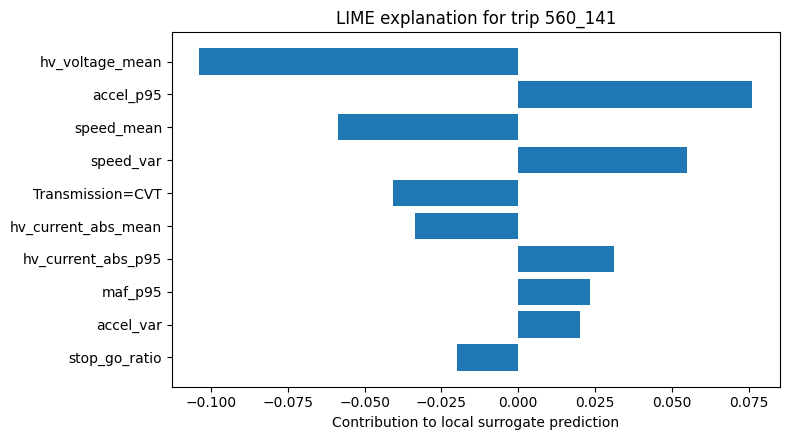

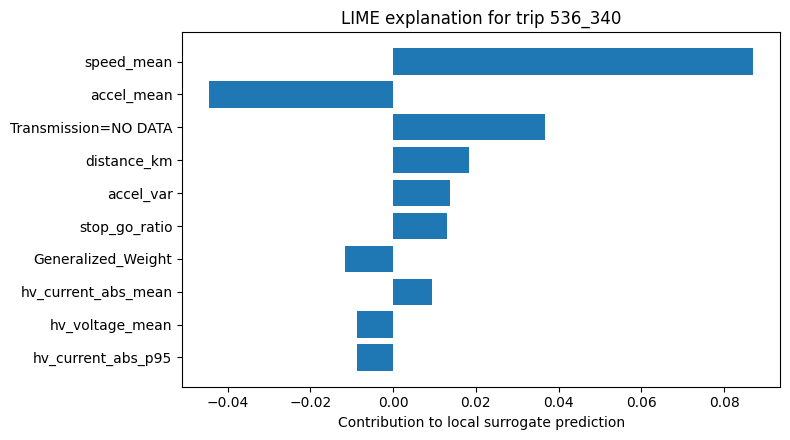

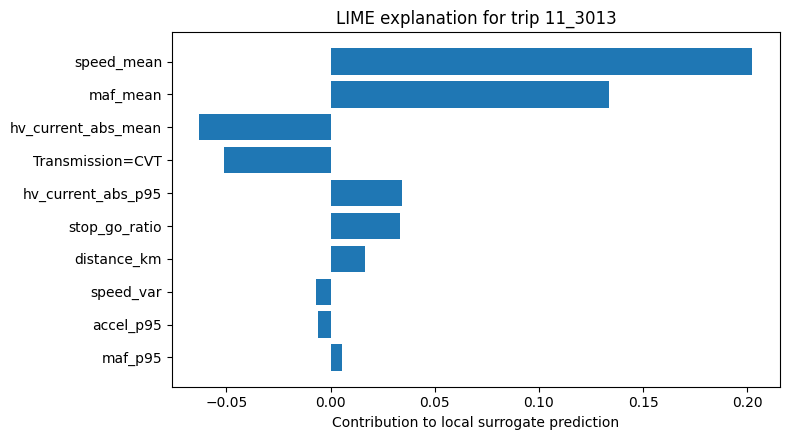

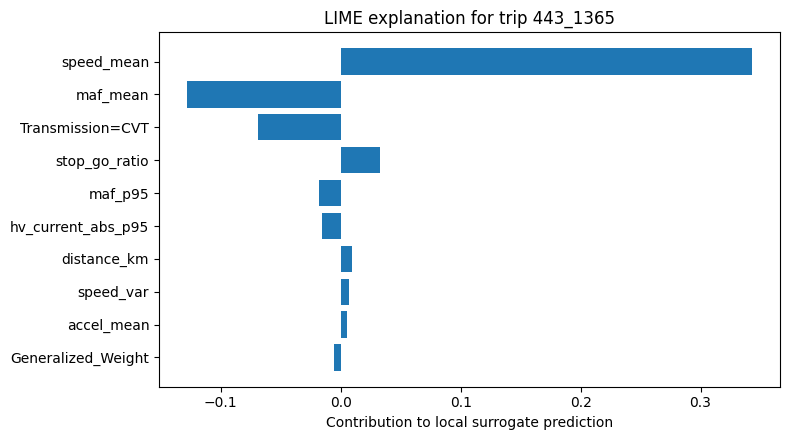

,trip_id,VehId,actual_energy_per_km,predicted_energy_per_km,residual,local_r2,local_rmse,x0_abs_gap,blackbox_prediction,surrogate_prediction_at_x0,top_features
0,560_141,560,2.2628,0.6627,1.6001,0.7617,0.0411,0.0000,0.6627,0.6627,hv_voltage_mean:-0.1038 | accel_p95:0.0762 | s...
1,536_340,536,1.5590,0.4924,1.0666,0.8114,0.0870,0.0165,0.4924,0.5088,speed_mean:0.0869 | accel_mean:-0.0444 | Trans...
2,11_3013,11,1.1895,0.8825,0.3070,0.7752,0.0791,0.0815,0.8825,0.8010,speed_mean:0.2025 | maf_mean:0.1336 | hv_curre...
3,443_1365,443,0.7369,0.4854,0.2515,0.8397,0.0795,0.0494,0.4854,0.5348,speed_mean:0.3427 | maf_mean:-0.1280 | Transmi...


In [14]:
lime_tuning_df = lime_tuning_df.dropna(subset=["median_local_r2", "median_local_rmse", "median_x0_abs_gap"]).reset_index(drop=True)
if lime_tuning_df.empty:
    raise RuntimeError("All LIME tuning configurations failed. Please inspect background_raw / feature availability.")
best_lime_row = lime_tuning_df.iloc[0].to_dict()
best_lime_params = {
    "n_samples": int(best_lime_row["n_samples"]),
    "kernel_width_factor": float(best_lime_row["kernel_width_factor"]),
    "ridge_alpha": float(best_lime_row["ridge_alpha"]),
    "top_k": TOP_K_FEATURES,
    "random_state": RANDOM_STATE,
}
print(json.dumps(best_lime_params, indent=2))

explain_candidates = (
    scored_df.loc[scored_df["is_anomaly"]]
    .sort_values("residual", ascending=False)
    .drop_duplicates(subset=["VehId"])
    .head(N_EXPLANATIONS)
    .reset_index(drop=True)
)

summary_rows = []

for _, row in explain_candidates.iterrows():
    exp, contrib_df = explain_one_trip_with_lime(
        x0_row=row,
        background_raw=background_raw,
        model_artifact=artifact,
        n_samples=best_lime_params["n_samples"],
        kernel_width_factor=best_lime_params["kernel_width_factor"],
        ridge_alpha=best_lime_params["ridge_alpha"],
        top_k=best_lime_params["top_k"],
        random_state=best_lime_params["random_state"],
    )

    safe_trip_id = str(exp.trip_id).replace("/", "_")
    contrib_path = EXPLAIN_DIR / f"trip_{safe_trip_id}_contributions.csv"
    json_path = EXPLAIN_DIR / f"trip_{safe_trip_id}_explanation.json"
    plot_path = EXPLAIN_DIR / f"trip_{safe_trip_id}_bar.png"

    contrib_df.to_csv(contrib_path, index=False)
    with open(json_path, "w", encoding="utf-8") as f:
        json.dump(asdict(exp), f, ensure_ascii=False, indent=2)

    plot_lime_contributions(
        contrib_df=contrib_df,
        title=f"LIME explanation for trip {exp.trip_id}",
        save_path=plot_path,
        top_k=TOP_K_FEATURES,
    )

    summary_rows.append({
        "trip_id": exp.trip_id,
        "VehId": row["VehId"],
        "actual_energy_per_km": float(row[TARGET]),
        "predicted_energy_per_km": float(row["predicted_energy_per_km"]),
        "residual": float(row["residual"]),
        "local_r2": exp.local_r2,
        "local_rmse": exp.local_rmse,
        "x0_abs_gap": exp.x0_abs_gap,
        "blackbox_prediction": exp.blackbox_prediction,
        "surrogate_prediction_at_x0": exp.surrogate_prediction_at_x0,
        "top_features": " | ".join([f"{name}:{value:.4f}" for name, value in exp.top_features]),
    })

explanation_summary_df = pd.DataFrame(summary_rows)
explanation_summary_df.to_csv(EXPLANATION_SUMMARY_PATH, index=False)

display(explanation_summary_df)

## 13. Final files produced by the notebook

After a full run you should have:

- `outputs_final/cache/trip_table_raw.csv.gz`
- `outputs_final/cache/trip_table_scored.csv.gz`
- `outputs_final/cache/xgb_tuning_results.csv`
- `outputs_final/cache/lime_tuning_results.csv`
- `outputs_final/models/xgb_energy_artifact.joblib`
- `outputs_final/plots/*.png`
- `outputs_final/lime_explanations/*.json`
- `outputs_final/lime_explanations/*.csv`
- `outputs_final/lime_explanations/*.png`


In [15]:
zip_path = PROJECT_ROOT / "output.zip"
with ZipFile(zip_path, "w") as zf:
    for fp in OUTPUT_DIR.rglob("*"):
        if fp.is_file():
            zf.write(fp, arcname=fp.relative_to(PROJECT_ROOT))

print(f"Saved zip archive: {zip_path}")

Saved zip archive: /kaggle/working/output.zip
